# Probability Distributions in AI/ML - Practice Notebook

This notebook contains conceptual and coding questions on Normal, Binomial, and Poisson distributions.

---

## 1. Normal Distribution

**Q1:** Generate a normal distribution with mean=0 and std=1. Plot it.

**Q2:** Simulate exam scores of 1000 students assuming normal distribution. What percentage scored above 85?

**Q3 (Thinking):** How does changing standard deviation affect the spread? Visualize.

In [30]:
# Your code here
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Generate data
data = np.random.normal(loc=0, scale=1, size=1000)

# Generate exam scores
scores = np.random.normal(loc=70, scale=10, size=1000)

# Calculate percentage above 85
above_85 = np.sum(scores > 85)
percentage = (above_85 / len(scores)) * 100

print("Percentage scoring above 85:", percentage)

Percentage scoring above 85: 5.0


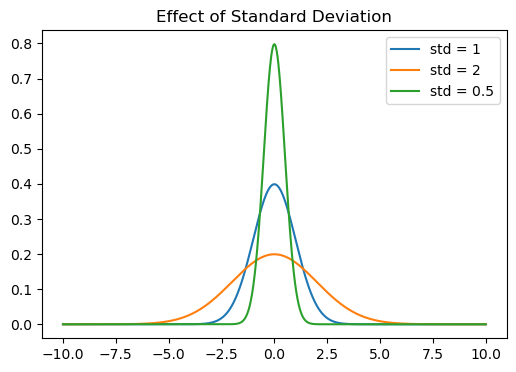

In [31]:
x = np.linspace(-10, 10, 1000)

# Different std values
std1 = 1
std2 = 2
std3 = 0.5

y1 = (1/(std1*np.sqrt(2*np.pi))) * np.exp(-0.5*(x/std1)**2)
y2 = (1/(std2*np.sqrt(2*np.pi))) * np.exp(-0.5*(x/std2)**2)
y3 = (1/(std3*np.sqrt(2*np.pi))) * np.exp(-0.5*(x/std3)**2)

plt.figure(figsize=(6,4))
plt.plot(x, y1, label="std = 1")
plt.plot(x, y2, label="std = 2")
plt.plot(x, y3, label="std = 0.5")

plt.legend()
plt.title("Effect of Standard Deviation")
plt.show()

## 2. Binomial Distribution

**Q4:** Simulate 100 coin toss experiments with probability p=0.5. Plot distribution.

**Q5:** Model a scenario where a student guesses MCQs (4 options). What is probability of getting exactly 6 correct out of 10?

**Q6 (Thinking):** When does binomial start resembling normal distribution? Demonstrate.

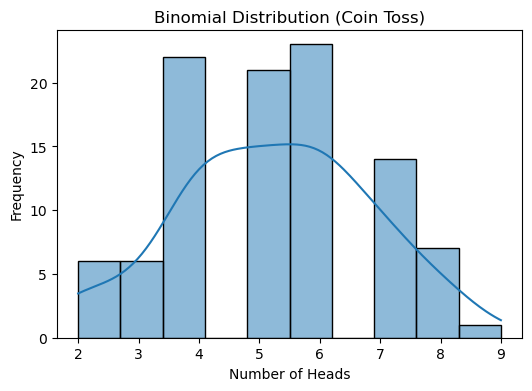

In [33]:
# Your code here
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 100 experiments, each with 10 tosses
data = np.random.binomial(n=10, p=0.5, size=100)

# Plot
plt.figure(figsize=(6,4))
sns.histplot(data, bins=10, kde=True)
plt.title("Binomial Distribution (Coin Toss)")
plt.xlabel("Number of Heads")
plt.ylabel("Frequency")
plt.show()


In [34]:
from scipy.stats import binom

n = 10
p = 0.25

prob = binom.pmf(6, n, p)
print("Probability of exactly 6 correct:", prob)

Probability of exactly 6 correct: 0.016222000122070295


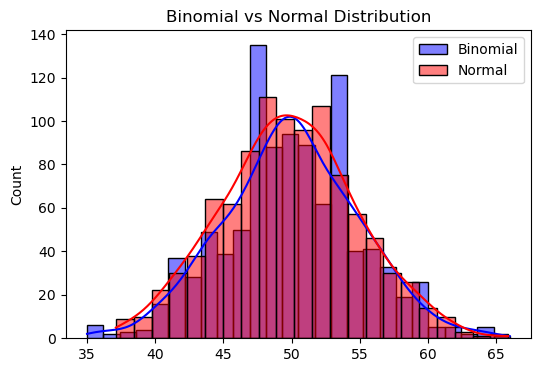

In [35]:
#Demonstration code
# Binomial data
binom_data = np.random.binomial(n=100, p=0.5, size=1000)

# Normal approximation
normal_data = np.random.normal(loc=50, scale=np.sqrt(100*0.5*0.5), size=1000)

plt.figure(figsize=(6,4))
sns.histplot(binom_data, color='blue', label='Binomial', kde=True)
sns.histplot(normal_data, color='red', label='Normal', kde=True)

plt.legend()
plt.title("Binomial vs Normal Distribution")
plt.show()

## 3. Poisson Distribution

**Q7:** Model number of calls received per minute in a call center (lambda=5).

**Q8:** What is probability of receiving exactly 3 calls in a minute?

**Q9 (Thinking):** When should Poisson be used instead of Binomial? Simulate example.
📌 Use Binomial when:
Condition	Explanation
Fixed trials	e.g., 10 questions
Two outcomes	success/failure
Probability fixed	same p every time

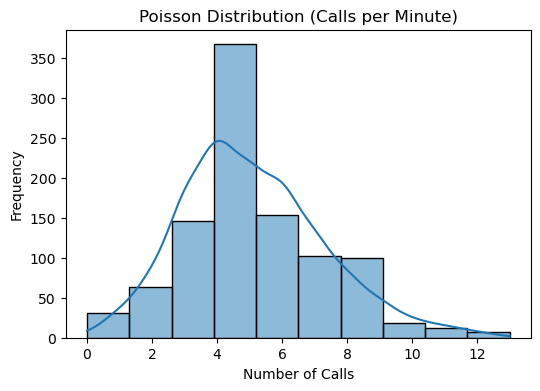

In [36]:
# Your code here
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# simulate 1000 minutes
data = np.random.poisson(lam=5, size=1000)

# plot
plt.figure(figsize=(6,4))
sns.histplot(data, bins=10, kde=True)
plt.title("Poisson Distribution (Calls per Minute)")
plt.xlabel("Number of Calls")
plt.ylabel("Frequency")
plt.show()

In [37]:
#Q8
from scipy.stats import poisson

prob = poisson.pmf(3, 5)
print("Probability of exactly 3 calls:", prob)

Probability of exactly 3 calls: 0.1403738958142805


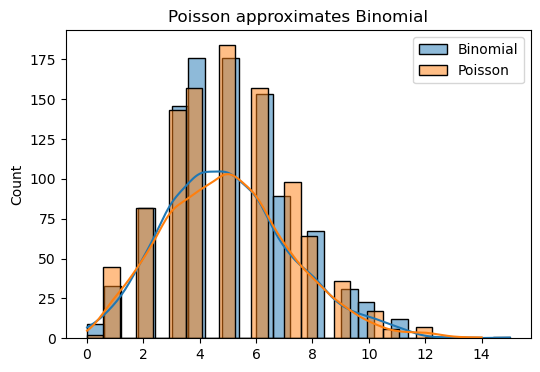

In [38]:
#simulation code
# Binomial (large n, small p)
binom_data = np.random.binomial(n=1000, p=0.005, size=1000)

# Poisson approximation
poisson_data = np.random.poisson(lam=5, size=1000)

plt.figure(figsize=(6,4))
sns.histplot(binom_data, label='Binomial', kde=True)
sns.histplot(poisson_data, label='Poisson', kde=True)

plt.legend()
plt.title("Poisson approximates Binomial")
plt.show()

## 4. Real-world Modeling + Pipeline

**Q10:** Create synthetic dataset where target follows a distribution.

**Q11:** Build a pipeline using sklearn that:
- Generates features
- Scales data
- Fits a model

**Q12 (Challenge):** Identify which distribution best fits given dataset.

In [39]:
#question 10
# Your code here
import numpy as np
import pandas as pd

np.random.seed(42)

# Features (X)
X = np.random.rand(1000, 3)   # 3 features

# Target (y) → Normal distribution
y = np.random.normal(loc=50, scale=10, size=1000)

# Create DataFrame
df = pd.DataFrame(X, columns=['feature1', 'feature2', 'feature3'])
df['target'] = y

print(df.head())

   feature1  feature2  feature3     target
0  0.374540  0.950714  0.731994  60.599364
1  0.598658  0.156019  0.155995  56.170059
2  0.058084  0.866176  0.601115  56.835693
3  0.708073  0.020584  0.969910  36.340443
4  0.832443  0.212339  0.181825  62.119440


In [40]:
#question 11
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Split data
X = df[['feature1','feature2','feature3']]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),   # Step 1: Scale
    ('model', LinearRegression())   # Step 2: Model
])

# Train
pipeline.fit(X_train, y_train)

# Predict
preds = pipeline.predict(X_test)

print("Predictions:", preds[:5])

Predictions: [50.15589224 50.79235825 50.21008283 50.28783457 50.36655862]


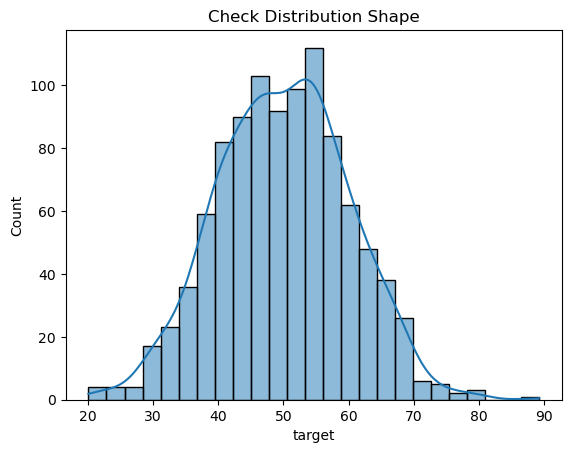

In [41]:
#Question 12
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['target'], kde=True)
plt.title("Check Distribution Shape")
plt.show()

In [42]:
#different distribution fits
from scipy import stats

# Fit normal
mu, std = stats.norm.fit(df['target'])

# Fit poisson (if integer data)
lam = np.mean(df['target'])

print("Normal fit:", mu, std)
print("Poisson lambda:", lam)

Normal fit: 50.02286883028127 10.04012969357801
Poisson lambda: 50.02286883028127


In [43]:
# Normality test
stat, p = stats.shapiro(df['target'])

print("P-value:", p)

if p > 0.05:
    print("Data is likely Normal")
else:
    print("Data is NOT Normal")

P-value: 0.6096709200306918
Data is likely Normal


## 🚨 Mini Project: Fraud Detection using Poisson Anomalies

A payment system records number of transactions per minute.

**Q13:** Simulate normal transaction behavior (λ = 5).

**Q14:** Inject anomalies (fraud spikes).

**Q15:** Detect anomalies using Poisson probability threshold.

**Q16 (Thinking):** How would you reduce false positives?


In [44]:
# Your code here
import numpy as np
import pandas as pd

np.random.seed(42)

# simulate 1000 minutes
normal_data = np.random.poisson(lam=5, size=1000)

df = pd.DataFrame({'transactions': normal_data})
print(df.head())


   transactions
0             5
1             4
2             4
3             5
4             5


In [45]:
# inject anomalies at random positions
anomaly_indices = np.random.choice(range(1000), size=20, replace=False)

df.loc[anomaly_indices, 'transactions'] = np.random.randint(15, 25, size=20)

# mark ground truth
df['is_anomaly'] = 0
df.loc[anomaly_indices, 'is_anomaly'] = 1

print(df.head())

   transactions  is_anomaly
0             5           0
1             4           0
2             4           0
3             5           0
4             5           0


In [46]:
#Q15: Detect Anomalies using Poisson Probability
from scipy.stats import poisson

lambda_ = 5

# compute probability of each value
df['prob'] = df['transactions'].apply(lambda x: poisson.pmf(x, lambda_))

# threshold (very small probability)
threshold = 0.01

# detect anomalies
df['predicted_anomaly'] = (df['prob'] < threshold).astype(int)

print(df.head())

   transactions  is_anomaly      prob  predicted_anomaly
0             5           0  0.175467                  0
1             4           0  0.175467                  0
2             4           0  0.175467                  0
3             5           0  0.175467                  0
4             5           0  0.175467                  0


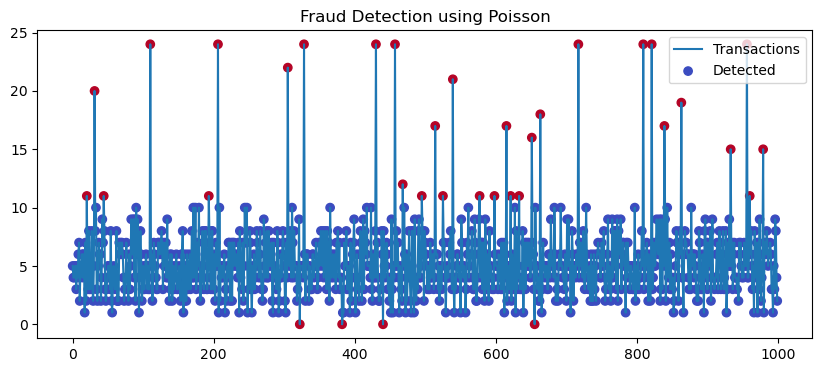

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(df['transactions'], label='Transactions')
plt.scatter(df.index, df['transactions'], 
            c=df['predicted_anomaly'], cmap='coolwarm', label='Detected')
plt.legend()
plt.title("Fraud Detection using Poisson")
plt.show()

In [61]:
#Q16: How to Reduce False Positives? (VERY IMPORTANT)

threshold = 0.005   # stricter than before

df['predicted_anomaly_v1'] = (df['prob'] < threshold).astype(int)

In [62]:
# rolling average (last 10 minutes)
df['rolling_mean'] = df['transactions'].rolling(window=10).mean()

# deviation from recent behavior
df['deviation'] = df['transactions'] - df['rolling_mean']

# anomaly if spike is too large
df['predicted_anomaly_v2'] = (df['deviation'] > 10).astype(int)

In [63]:
df['final_anomaly'] = (
    (df['prob'] < 0.001) & 
    (df['deviation'] > 8)
).astype(int)

In [64]:
from sklearn.metrics import classification_report

print(classification_report(df['is_anomaly'], df['final_anomaly']))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       1.00      1.00      1.00        20

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



## 🎛 Interactive Visualization (ipywidgets)

**Q17:** Create sliders for:
- Mean (μ)
- Standard deviation (σ)
- Lambda (λ)

Plot distributions dynamically.


In [65]:
# Your code here
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import interact, FloatSlider, IntSlider

sns.set(style="whitegrid")

# Function to plot distributions
def plot_distributions(mu=0.0, sigma=1.0, lam=5):
    plt.figure(figsize=(10,4))
    
    # Normal Distribution
    normal_data = np.random.normal(loc=mu, scale=sigma, size=1000)
    sns.histplot(normal_data, color='blue', kde=True, label='Normal', stat='density', alpha=0.6)
    
    # Poisson Distribution
    poisson_data = np.random.poisson(lam=lam, size=1000)
    sns.histplot(poisson_data, color='red', kde=False, label='Poisson', stat='density', alpha=0.6)
    
    plt.title("Interactive Distributions")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

# Create interactive sliders
interact(plot_distributions,
         mu=FloatSlider(value=0.0, min=-10, max=10, step=0.5, description='Mean μ'),
         sigma=FloatSlider(value=1.0, min=0.1, max=10, step=0.1, description='Std σ'),
         lam=IntSlider(value=5, min=1, max=20, step=1, description='Lambda λ'));

interactive(children=(FloatSlider(value=0.0, description='Mean μ', max=10.0, min=-10.0, step=0.5), FloatSlider…

## 📊 Distribution Fitting

**Q18:** Given a dataset, fit Normal, Poisson, and Binomial distributions.

**Q19:** Use likelihood or visual comparison to decide best fit.


In [67]:
# Your code here
import numpy as np
from scipy import stats

# Example dataset (integer counts)
data = np.random.poisson(lam=5, size=1000)
#normal distribution
mu, std = stats.norm.fit(data)
print(f"Normal fit: mu = {mu:.2f}, sigma = {std:.2f}")
#Fit Poisson Distribution
lam = np.mean(data)
print(f"Poisson fit: lambda = {lam:.2f}")
#Fit Binomial Distribution
n = max(data)  # assume max possible count
p = np.mean(data)/n
print(f"Binomial fit: n = {n}, p = {p:.2f}")



Normal fit: mu = 5.00, sigma = 2.28
Poisson fit: lambda = 5.00
Binomial fit: n = 13, p = 0.38


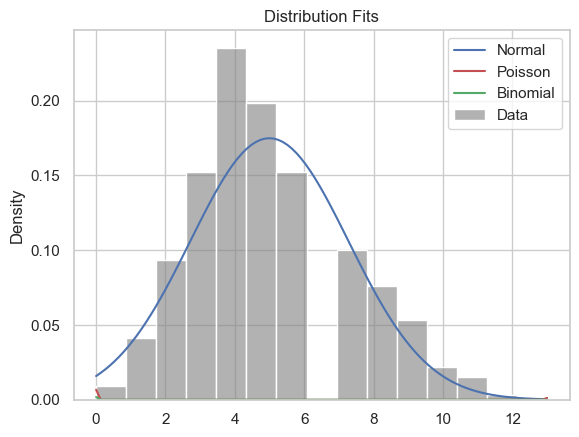

In [68]:
#Q19: Decide Best Fi
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(data, bins=15, color='gray', stat='density', alpha=0.6, label='Data')

# Normal PDF
x = np.linspace(min(data), max(data), 100)
plt.plot(x, stats.norm.pdf(x, mu, std), 'b-', label='Normal')

# Poisson PMF
poisson_probs = stats.poisson.pmf(x, lam)
plt.plot(x, poisson_probs, 'r-', label='Poisson')

# Binomial PMF
binom_probs = stats.binom.pmf(x, n, p)
plt.plot(x, binom_probs, 'g-', label='Binomial')

plt.legend()
plt.title("Distribution Fits")
plt.show()

In [69]:
# Log-likelihood for each distribution
ll_normal = np.sum(stats.norm.logpdf(data, mu, std))
ll_poisson = np.sum(stats.poisson.logpmf(data, lam))
ll_binomial = np.sum(stats.binom.logpmf(data, n, p))

print(f"Log-likelihoods:\nNormal: {ll_normal:.2f}\nPoisson: {ll_poisson:.2f}\nBinomial: {ll_binomial:.2f}")

Log-likelihoods:
Normal: -2243.36
Poisson: -2221.25
Binomial: -2317.42


## 🌍 Real Dataset Integration

**Q20:** Load real dataset (e.g., traffic, rainfall, or stock data).

**Q21:** Identify which distribution best models the data.

**Q22 (Challenge):** Build a small ML model using this dataset.


In [ ]:
# Your code here
